In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [4]:
def sir_model(t, y, beta, gamma):
    S, I, R = y
    dS_dt = -beta * S * I
    dI_dt = beta * S * I - gamma * I
    dR_dt = gamma * I
    return [dS_dt, dI_dt, dR_dt]

In [7]:
beta = 0.3   # Infektionsrate
gamma = 0.1  # Genesungsrate

S0, I0, R0 = 0.99, 0.01, 0.0 
y0 = [S0, I0, R0]
t_max = 160
dt = 1.0
t_points = np.arange(0, t_max + dt, dt)

In [8]:
def euler_solver(f, y0, t_points, beta, gamma):
    y = np.zeros((len(t_points), len(y0)))
    y[0] = y0
    for i in range(1, len(t_points)):
        t = t_points[i - 1]
        y[i] = y[i - 1] + dt * np.array(f(t, y[i - 1], beta, gamma))
    return y

sir_euler = euler_solver(sir_model, y0, t_points, beta, gamma)

In [9]:
def rk4_solver(f, y0, t_points, beta, gamma):
    y = np.zeros((len(t_points), len(y0)))
    y[0] = y0
    for i in range(1, len(t_points)):
        t = t_points[i - 1]
        y_prev = y[i - 1]
        
        k1 = np.array(f(t, y_prev, beta, gamma))
        k2 = np.array(f(t + dt/2, y_prev + dt/2 * k1, beta, gamma))
        k3 = np.array(f(t + dt/2, y_prev + dt/2 * k2, beta, gamma))
        k4 = np.array(f(t + dt, y_prev + dt * k3, beta, gamma))
        
        y[i] = y_prev + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return y

sir_rk4 = rk4_solver(sir_model, y0, t_points, beta, gamma)

In [10]:
solution_scipy = solve_ivp(
    lambda t, y: sir_model(t, y, beta, gamma),
    [0, t_max],
    y0,
    t_eval=t_points,
    method='BDF' # Viele Mögliche Methoden, je nach Art der Differentialgleichung
)  

sir_scipy = solution_scipy.y.T

Lest mal in der [Doku](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp) rum!

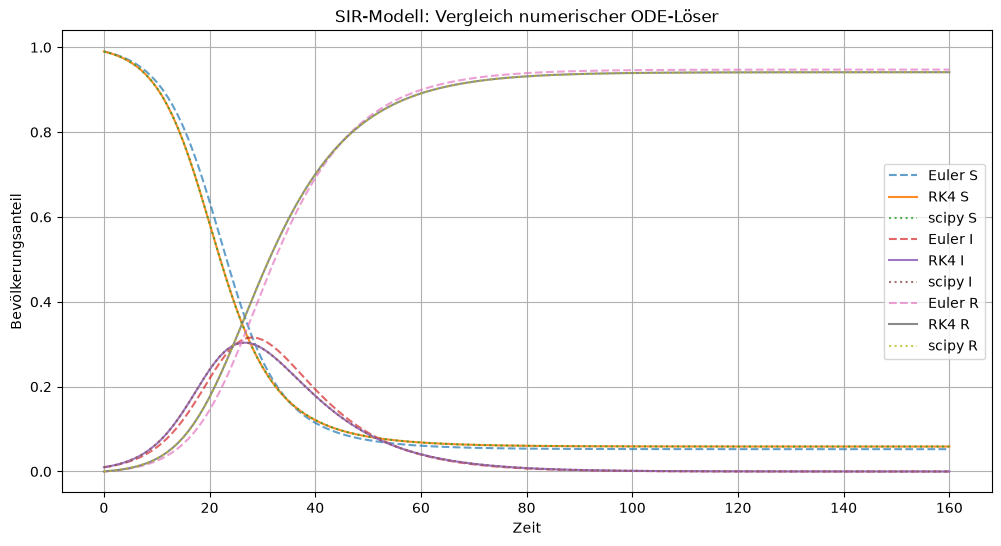

In [12]:
plt.figure(figsize=(12, 6))
labels = ['S', 'I', 'R']
for i in range(3):
    plt.plot(t_points, sir_euler[:, i], '--', label=f'Euler {labels[i]}', alpha=0.7)
    plt.plot(t_points, sir_rk4[:, i], '-', label=f'RK4 {labels[i]}', alpha=0.9)
    plt.plot(t_points, sir_scipy[:, i], ':', label=f'scipy {labels[i]}', alpha=0.8)

plt.xlabel('Zeit')
plt.ylabel('Bevölkerungsanteil')
plt.title('SIR-Modell: Vergleich numerischer ODE-Löser')
plt.legend()
plt.grid(True)
plt.show()